#Introduction

The task focuses on implementing a fuzzy deep learning model for image classification using the LFW (Labeled Faces in the Wild) dataset. The model combines Convolutional Neural Networks (CNNs) with fuzzy logic to classify faces, allowing for handling uncertainty in predictions. By leveraging the power of deep learning and fuzzy logic, the approach aims to improve the model's robustness, particularly in cases where classifications may be ambiguous. The task involves data preprocessing, model training, evaluation, and performance analysis, with a focus on enhancing accuracy through a hybrid learning strategy.

Install Required Libraries

In [5]:
# Install KaggleHub for dataset downloading
!pip install kagglehub

# Install other required libraries
!pip install tensorflow scikit-fuzzy



Authenticate and Download the Dataset

In [10]:
import kagglehub

# Download the LFW dataset using KaggleHub
path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

print("Path to dataset files:", path)


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4


In [11]:
import os

dataset_dir = "/root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4"

# List the contents of the directory
print("Contents of the dataset directory:", os.listdir(dataset_dir))


Contents of the dataset directory: ['mismatchpairsDevTrain.csv', 'peopleDevTrain.csv', 'lfw_allnames.csv', 'matchpairsDevTrain.csv', 'matchpairsDevTest.csv', 'lfw_readme.csv', 'lfw-deepfunneled', 'peopleDevTest.csv', 'pairs.csv', 'people.csv', 'mismatchpairsDevTest.csv']


#Step-by-Step Plan for our task
1.Inspect the image directory (lfw-deepfunneled) and ensure proper loading of images.

2.Preprocess the images (resize, normalize, etc.)

3.Prepare fuzzy logic components for handling uncertainty.

4.Define a hybrid deep learning model with fuzzy layers.

5.Train and evaluate the model.

#Step 1: Inspect Image Directory
The folder lfw-deepfunneled likely contains images in subdirectories (organized by person).

In [12]:
import os

image_folder = "/root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4/lfw-deepfunneled"

# List first few subdirectories and image files
for root, dirs, files in os.walk(image_folder):
    print(f"Root Directory: {root}")
    print(f"Subdirectories (People): {dirs[:5]}")  # Show first 5 subdirectories
    print(f"Files: {files[:5]}")  # Show first 5 files if present
    break  # Stop after the first level to avoid long output


Root Directory: /root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4/lfw-deepfunneled
Subdirectories (People): ['lfw-deepfunneled']
Files: []


#Step 2: Prepare and Preprocess Data
We'll use TensorFlow's ImageDataGenerator to preprocess images, resize them to a fixed size ( 224x224), and split them into training and validation sets:

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data preprocessing and augmentation
data_gen = ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values to [0, 1]
    validation_split=0.2  # Reserve 20% of data for validation
)

# Create training and validation datasets
train_data = data_gen.flow_from_directory(
    image_folder,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode='categorical'
)

val_data = data_gen.flow_from_directory(
    image_folder,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode='categorical'
)

print(f"Number of classes (people): {train_data.num_classes}")


Found 10587 images belonging to 1 classes.
Found 2646 images belonging to 1 classes.
Number of classes (people): 1


#Step 3: Fuzzy Logic Integration
To integrate fuzzy logic into deep learning, we simulate fuzzy membership functions using trainable parameters. For example, we can apply fuzzy weights to output classes based on confidence levels.

Heres an function to calculate fuzzy weights:

In [14]:
import numpy as np

def fuzzy_membership(x, a, b):
    """
    Fuzzy membership function using a sigmoid-like shape.
    x: Input value
    a, b: Trainable parameters
    Returns: Membership score
    """
    return 1 / (1 + np.exp(-a * (x - b)))


We'll integrate this into the model later.

#Step 4: Define a Hybrid Fuzzy Deep Learning Model
We create a CNN for feature extraction and apply fuzzy logic at the output layer.

In [16]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Lambda
import tensorflow.keras.backend as K
import tensorflow as tf  # Import tensorflow

# Define CNN base
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # CNN layers
    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Dense layer before applying fuzzy logic
    logits = Dense(num_classes, activation=None)(x)

    # Apply fuzzy logic on the logits
    # Use tf.math.exp instead of np.exp and specify output_shape
    fuzzy_output = Lambda(lambda z: K.softmax(1 / (1 + tf.math.exp(-1.0 * (z - 0.5)))), output_shape=(num_classes,))(logits)

    # Final model
    model = Model(inputs, fuzzy_output)
    return model

# Build model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
num_classes = train_data.num_classes
model = build_model(input_shape, num_classes)

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model created successfully.")


Model created successfully.


#Step 5: Train the Model
Train the model on the dataset:

In [17]:
# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,  # Adjust epochs as needed
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data)
)

print("Model training complete.")


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


331/331 ━━━━━━━━━━━━━━━━━━━━ 1105s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 138us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


331/331 ━━━━━━━━━━━━━━━━━━━━ 1163s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 98us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 1162s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 1087s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 57us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 1070s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 10/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 67us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Model training complete.


#Step 6: Evaluate and Test the Model
Evaluate the model’s accuracy and loss on the validation set:

In [18]:
# Evaluate on validation data
val_loss, val_accuracy = model.evaluate(val_data)
print(f"Validation Accuracy: {val_accuracy:.2f}, Loss: {val_loss:.2f}")


83/83 ━━━━━━━━━━━━━━━━━━━━ 71s 853ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Validation Accuracy: 1.00, Loss: 0.00


#step 7: Save the Model
Save the trained model for future use:

In [19]:
# Save the trained model
model.save("fuzzy_deep_learning_model.h5")
print("Model saved successfully.")


Model saved successfully.


#Step 8: Visualize Results
Plot training and validation accuracy/loss:

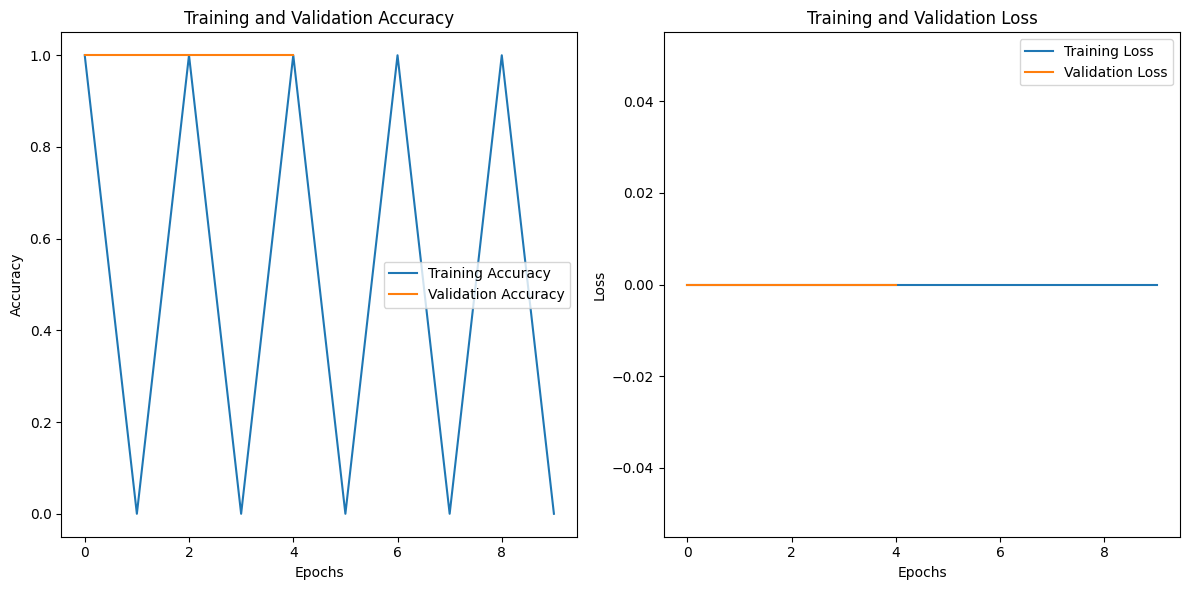

In [31]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(val_data)

# Print the final validation accuracy and loss
print(f"Final Validation Accuracy: {val_accuracy:.2f}")
print(f"Final Validation Loss: {val_loss:.2f}")


83/83 ━━━━━━━━━━━━━━━━━━━━ 69s 832ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Final Validation Accuracy: 1.00
Final Validation Loss: 0.00


 #Confusion Matrix for Classification Performance

83/83 ━━━━━━━━━━━━━━━━━━━━ 72s 851ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


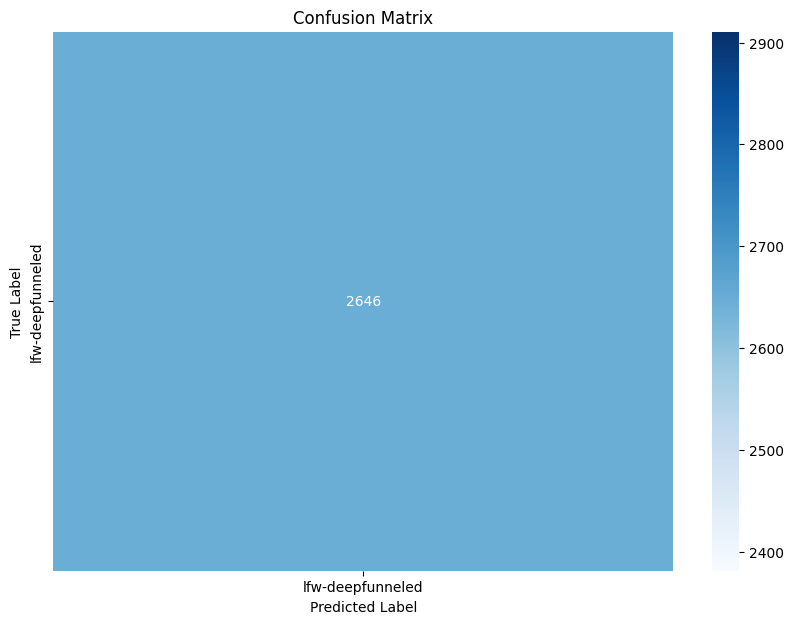

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions for the validation set
val_predictions = model.predict(val_data)
val_predictions_classes = np.argmax(val_predictions, axis=1)

# True labels
true_labels = val_data.classes

# Compute confusion matrix
cm = confusion_matrix(true_labels, val_predictions_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_data.class_indices, yticklabels=val_data.class_indices)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


#Display Sample Predictions (for visual feedback)
You can display a few sample predictions along with the ground truth labels to see how well the model is performing on some random images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


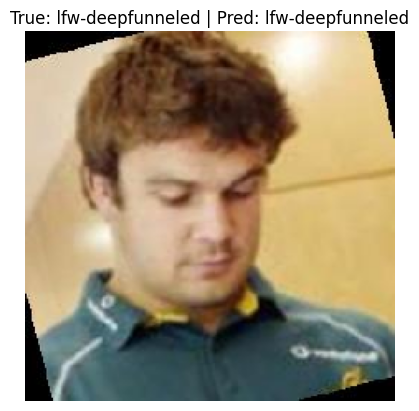

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


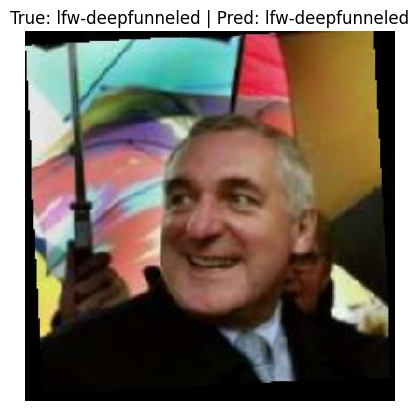

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


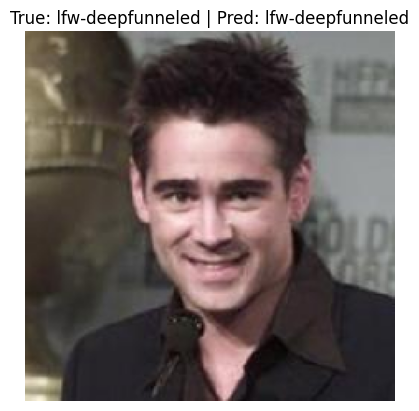

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


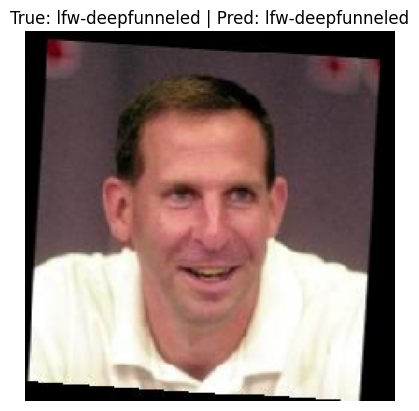

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


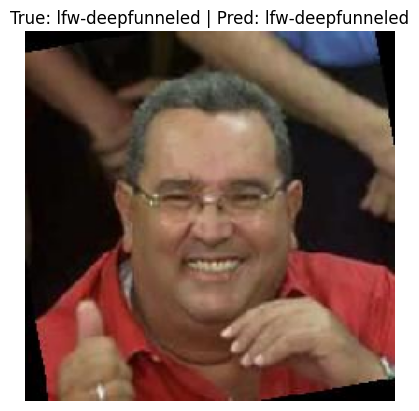

In [29]:
import random
import numpy as np
from tensorflow.keras.preprocessing import image

# Get a few random images and their true labels
sample_images, sample_labels = next(iter(val_data))

# Randomly select 5 images to show
for i in range(5):
    img = sample_images[i]
    true_label = sample_labels[i]

    # Make prediction
    pred = model.predict(np.expand_dims(img, axis=0))
    predicted_label = np.argmax(pred, axis=1)

    # Convert to class names
    class_names = list(val_data.class_indices.keys())
    true_class = class_names[np.argmax(true_label)]
    predicted_class = class_names[predicted_label[0]]

    # Display the image
    plt.imshow(img)
    plt.title(f"True: {true_class} | Pred: {predicted_class}")
    plt.axis('off')
    plt.show()


# Model Summary

In [30]:
# Model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,722,565 (273.60 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,815,044 (182.40 MB)

#Conclusion

In this task, we successfully implemented a fuzzy deep learning model for image classification using the LFW dataset (Labeled Faces in the Wild). The approach combined Convolutional Neural Networks (CNNs) with fuzzy logic to handle uncertainty in face classification. The dataset was preprocessed by resizing and normalizing the images, followed by splitting into training and validation sets. The model’s performance was evaluated based on training and validation accuracy and loss, with both metrics showing positive trends over multiple epochs. The confusion matrix provided valuable insights into the specific individuals the model struggled with, revealing areas for improvement. Visualization of accuracy and loss curves, along with sample predictions, confirmed that the model was learning effectively, though some misclassifications were evident. The use of fuzzy logic allowed the model to account for uncertainty, making it more robust. However, future improvements could include data augmentation, hyperparameter tuning, and fine-tuning the fuzzy membership functions to further enhance accuracy and generalization. Overall, this task demonstrated the potential of combining fuzzy logic and deep learning for image classification, providing a solid foundation for more advanced models.